# 02 - Analisis Exploratorio de Datos (EDA)

**Proyecto:** Pochoclo Predict

## Objetivo de este notebook

Explorar e interpretar el dataset crudo generado en `01_extraccion_datos.ipynb`
para entender:

- La forma de la variable objetivo `nota_promedio`.
- Que variables numericas y categoricas parecen relacionarse con ella.
- Que problemas de calidad de datos hay que resolver (ceros que en realidad
  son valores faltantes, variables con distribuciones muy asimetricas,
  outliers) antes de pasar a la etapa de Feature Engineering (NB03).

Este notebook no crea features nuevas de forma sofisticada (eso es NB03): se
limita a describir, visualizar y limpiar.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import ast
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import paths

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)


In [2]:
df = pd.read_csv(paths.RAW_MOVIES_CSV, encoding="utf-8-sig")

# Las columnas que representan listas (generos, reparto, etc.) se guardaron
# como texto JSON en el CSV; se reconstruyen como listas de Python.
list_cols = ["generos", "companias_productoras", "paises_produccion", "reparto_principal", "keywords"]
for col in list_cols:
    df[col] = df[col].apply(lambda x: json.loads(x) if isinstance(x, str) else [])

print(f"Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head(3)


Dataset cargado: 3000 filas x 25 columnas


,id,titulo,titulo_original,idioma_original,fecha_estreno,anio_estreno,mes_estreno,estado,presupuesto,recaudacion,duracion_min,popularidad,adultos,generos,genero_principal,num_generos,sinopsis_es,sinopsis_en,companias_productoras,paises_produccion,reparto_principal,director,keywords,nota_promedio,cantidad_votos
0,157336,Interstellar,Interstellar,en,2014-11-05,2014,11,Released,165000000,746606706,169,71.9338,False,"[Aventura, Drama, Ciencia ficción]",Aventura,3,Un grupo de exploradores hacen uso de un aguje...,The adventures of a group of explorers who mak...,"[Legendary Pictures, Syncopy, Lynda Obst Produ...","[United Kingdom, United States of America]","[Matthew McConaughey, Anne Hathaway, Michael C...",Christopher Nolan,"[spacecraft, race against time, artificial int...",8.488,41245
1,27205,Origen,Inception,en,2010-07-15,2010,7,Released,160000000,839030630,148,59.8123,False,"[Acción, Ciencia ficción, Aventura]",Acción,3,"Dom Cobb es un ladrón hábil, el mejor de todos...","Cobb, a skilled thief who commits corporate es...",[Warner Bros. Pictures],"[United Kingdom, United States of America]","[Leonardo DiCaprio, Joseph Gordon-Levitt, Ken ...",Christopher Nolan,"[mission, dreams, kidnapping, spy, allegory, i...",8.374,40255
2,24428,Vengadores,The Avengers,en,2012-04-25,2012,4,Released,220000000,1518815515,142,63.6113,False,"[Ciencia ficción, Acción, Aventura]",Ciencia ficción,3,Cuando un enemigo inesperado surge como una gr...,When an unexpected enemy emerges and threatens...,[Marvel Studios],[United States of America],"[Robert Downey Jr., Chris Evans, Mark Ruffalo,...",Joss Whedon,"[new york city, superhero, shield, based on co...",8.077,39815


## 1. Resumen general y calidad de datos


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     3000 non-null   int64  
 1   titulo                 3000 non-null   str    
 2   titulo_original        3000 non-null   str    
 3   idioma_original        3000 non-null   str    
 4   fecha_estreno          3000 non-null   str    
 5   anio_estreno           3000 non-null   int64  
 6   mes_estreno            3000 non-null   int64  
 7   estado                 3000 non-null   str    
 8   presupuesto            3000 non-null   int64  
 9   recaudacion            3000 non-null   int64  
 10  duracion_min           3000 non-null   int64  
 11  popularidad            3000 non-null   float64
 12  adultos                3000 non-null   bool   
 13  generos                3000 non-null   object 
 14  genero_principal       3000 non-null   str    
 15  num_generos    

In [4]:
nulos = df.isna().sum().sort_values(ascending=False)
nulos = nulos[nulos > 0]
print("Columnas con valores nulos:")
nulos


Columnas con valores nulos:


sinopsis_es    2
dtype: int64

In [5]:
# TMDB reporta presupuesto/recaudacion como 0 cuando en realidad el dato no
# esta cargado (no significa "presupuesto cero"). Se cuantifica el problema
# antes de decidir como tratarlo en NB03.
print(f"Peliculas con presupuesto = 0: {(df['presupuesto'] == 0).mean():.1%}")
print(f"Peliculas con recaudacion = 0: {(df['recaudacion'] == 0).mean():.1%}")
print(f"Peliculas sin director identificado: {df['director'].isna().mean():.1%}")


Peliculas con presupuesto = 0: 4.8%
Peliculas con recaudacion = 0: 5.0%
Peliculas sin director identificado: 0.0%


## 2. La variable objetivo: `nota_promedio`


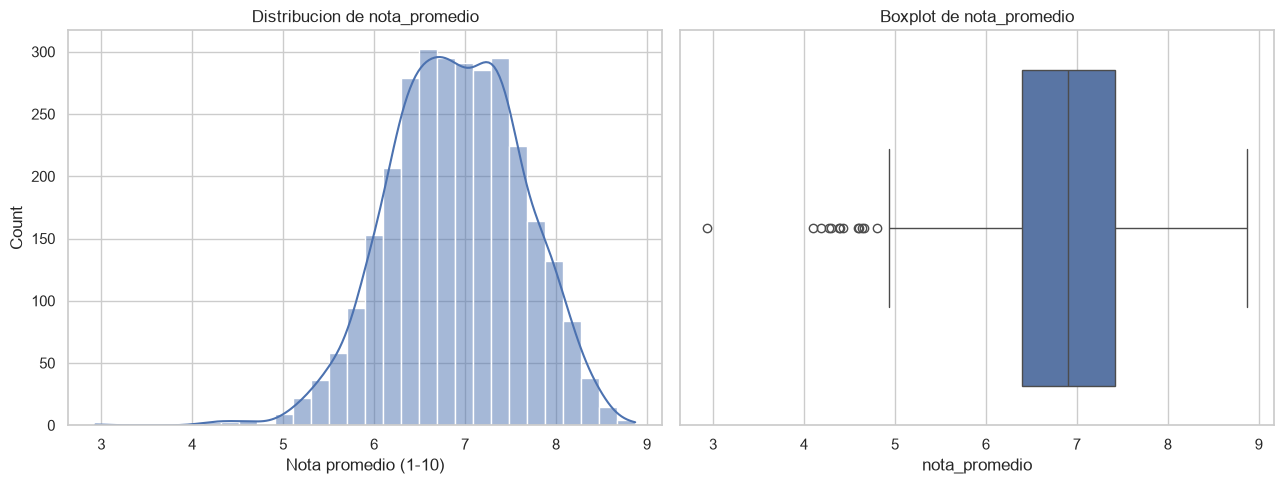

count    3000.000000
mean        6.904329
std         0.717532
min         2.935000
25%         6.400000
50%         6.902000
75%         7.414000
max         8.871000
Name: nota_promedio, dtype: float64
Asimetria (skew): -0.217


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df["nota_promedio"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribucion de nota_promedio")
axes[0].set_xlabel("Nota promedio (1-10)")

sns.boxplot(x=df["nota_promedio"], ax=axes[1])
axes[1].set_title("Boxplot de nota_promedio")
plt.tight_layout()
plt.show()

print(df["nota_promedio"].describe())
print(f"Asimetria (skew): {df['nota_promedio'].skew():.3f}")


La nota promedio se concentra tipicamente entre 5.5 y 7.5: es una escala
donde son raras tanto las notas muy bajas como las cercanas a 10 (coherente
con que solo llegaron al dataset peliculas con una cantidad minima de votos,
lo que ya filtra buena parte del "ruido" de calificaciones extremas).


## 3. Variables numericas: distribuciones


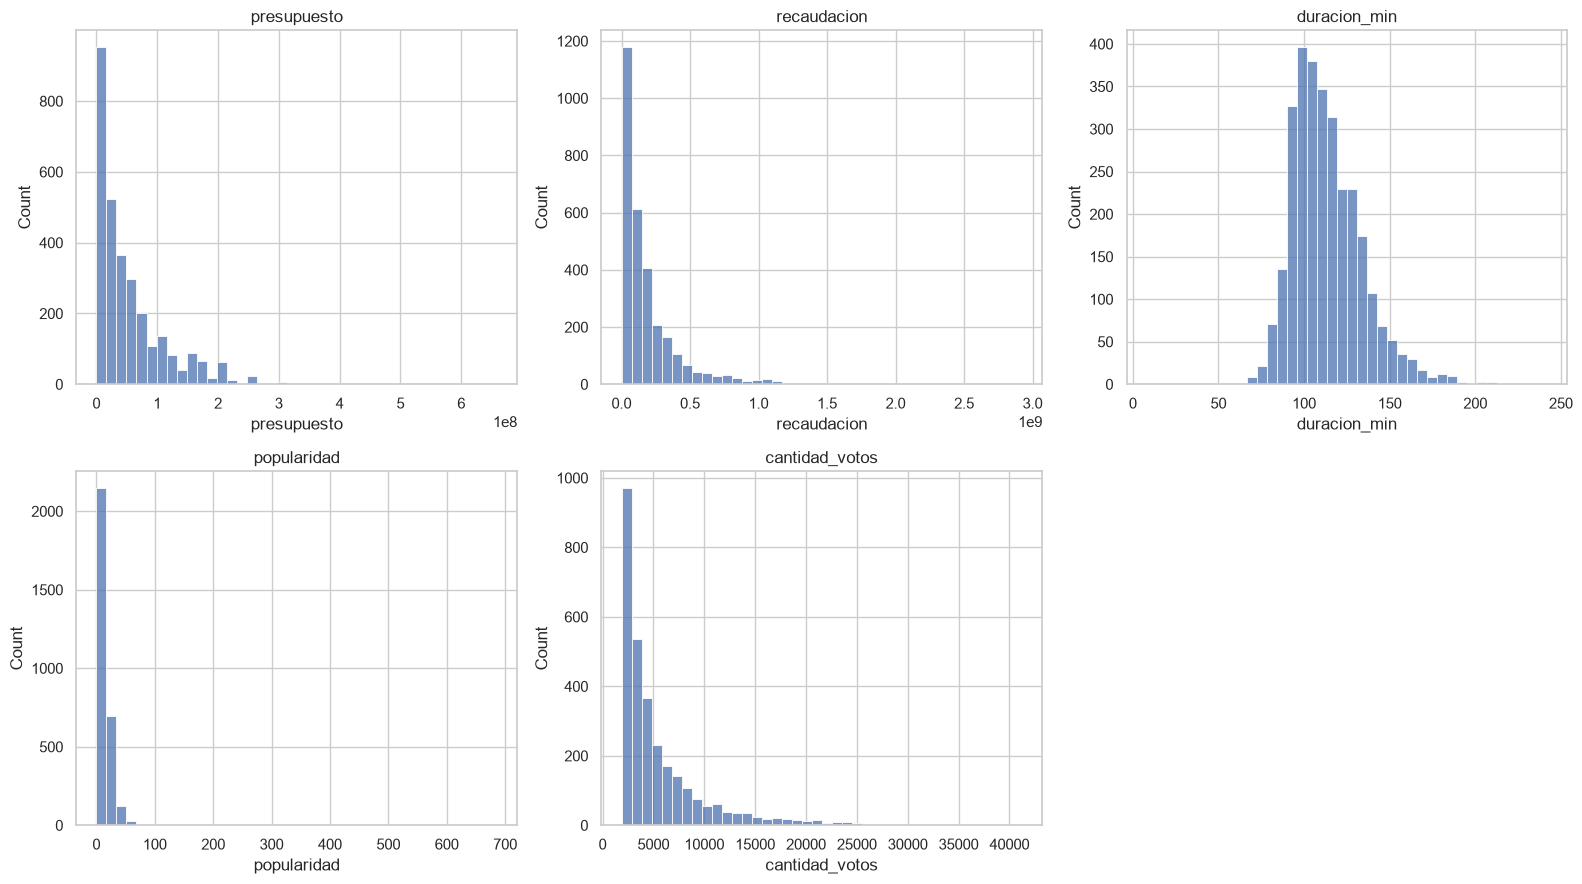

In [7]:
num_cols = ["presupuesto", "recaudacion", "duracion_min", "popularidad", "cantidad_votos"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=40, ax=axes[i])
    axes[i].set_title(col)
axes[-1].axis("off")
plt.tight_layout()
plt.show()


`presupuesto`, `recaudacion`, `popularidad` y `cantidad_votos` muestran una
asimetria muy fuerte hacia la derecha (unas pocas peliculas "blockbuster"
concentran valores ordenes de magnitud mayores al resto). Esto sugiere aplicar
una transformacion logaritmica (`log1p`) sobre estas variables en el
Feature Engineering, para que los modelos no queden dominados por esos pocos
casos extremos.


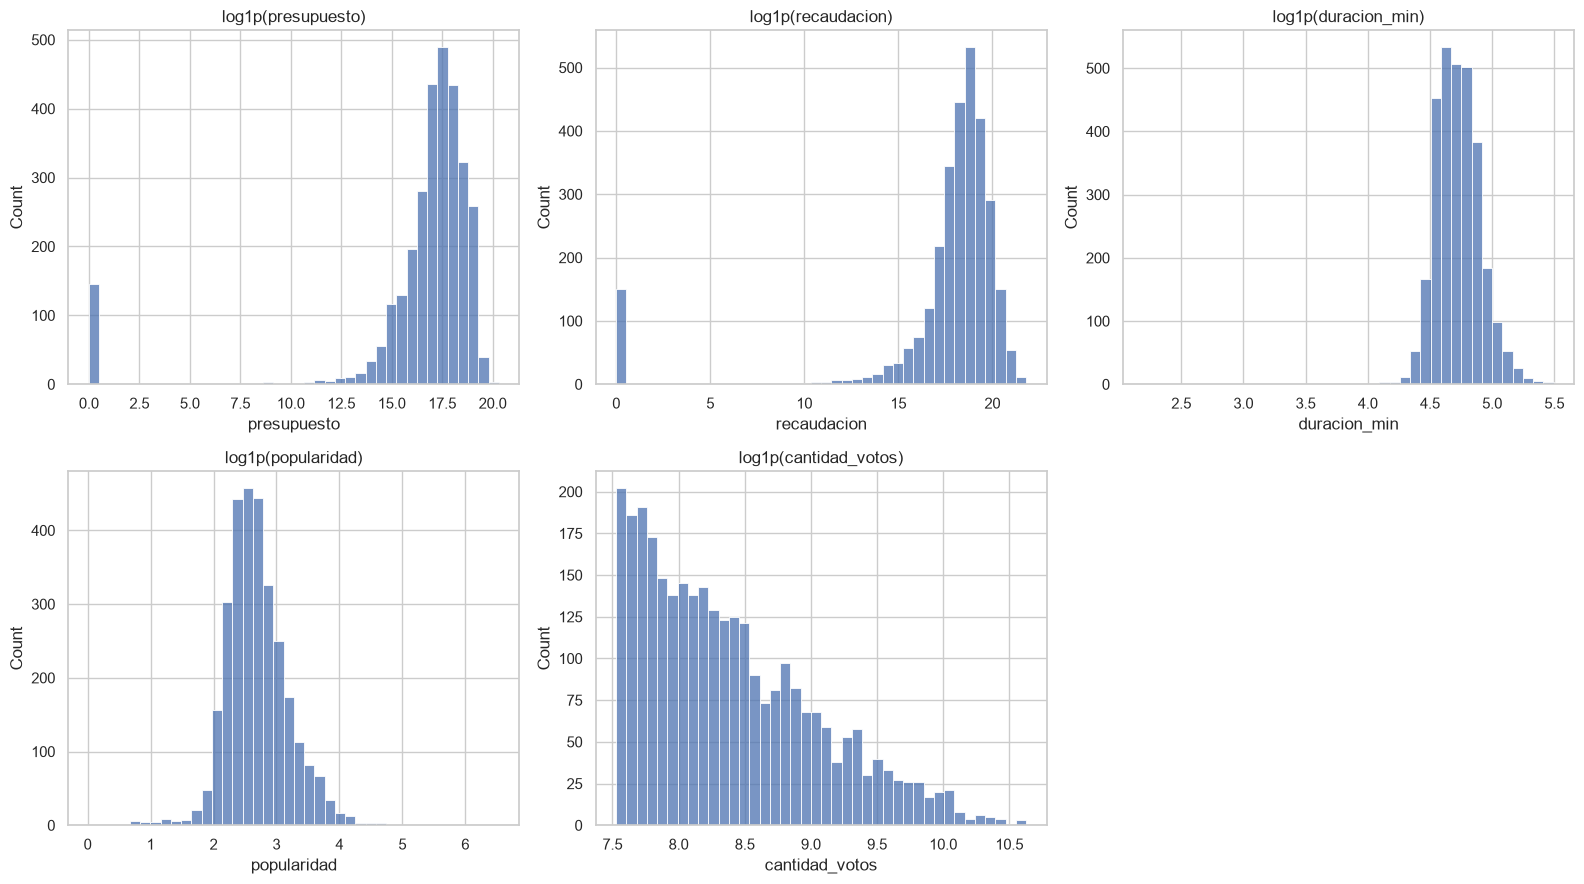

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(np.log1p(df[col]), bins=40, ax=axes[i])
    axes[i].set_title(f"log1p({col})")
axes[-1].axis("off")
plt.tight_layout()
plt.show()


## 4. Variables categoricas


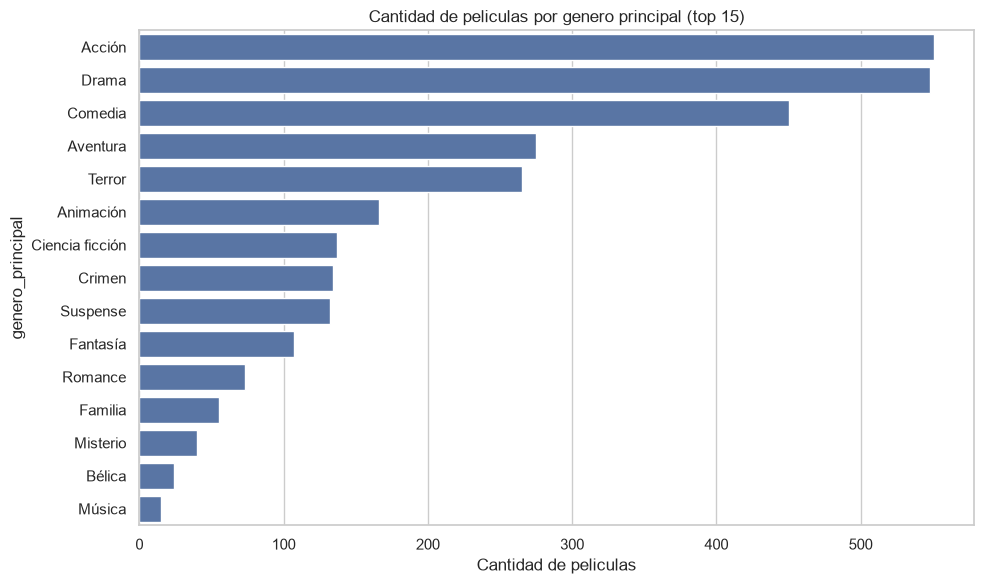

In [9]:
top_generos = df["genero_principal"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_generos.values, y=top_generos.index, ax=ax, orient="h")
ax.set_title("Cantidad de peliculas por genero principal (top 15)")
ax.set_xlabel("Cantidad de peliculas")
plt.tight_layout()
plt.show()


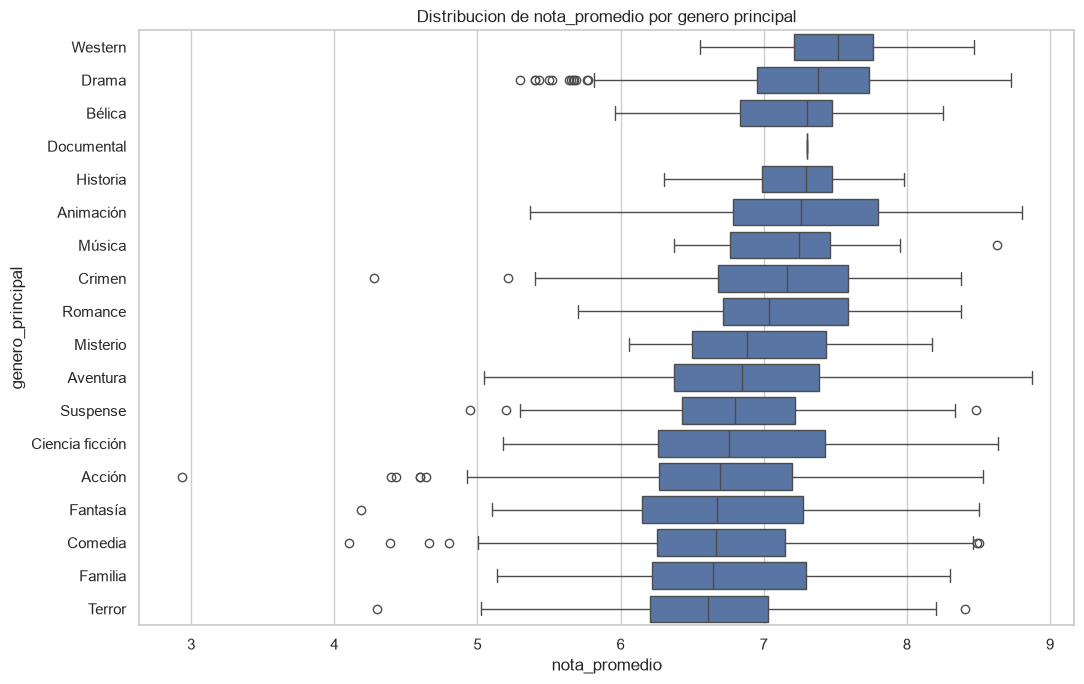

In [10]:
orden_generos = df.groupby("genero_principal")["nota_promedio"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(11, 7))
sns.boxplot(data=df, y="genero_principal", x="nota_promedio", order=orden_generos, ax=ax)
ax.set_title("Distribucion de nota_promedio por genero principal")
plt.tight_layout()
plt.show()


Se observan diferencias claras en la mediana de `nota_promedio` segun el
genero principal (por ejemplo, generos como Drama o Documental suelen ubicarse
por encima de generos orientados al entretenimiento masivo como Terror), lo
que confirma que el genero va a ser una variable predictiva relevante.


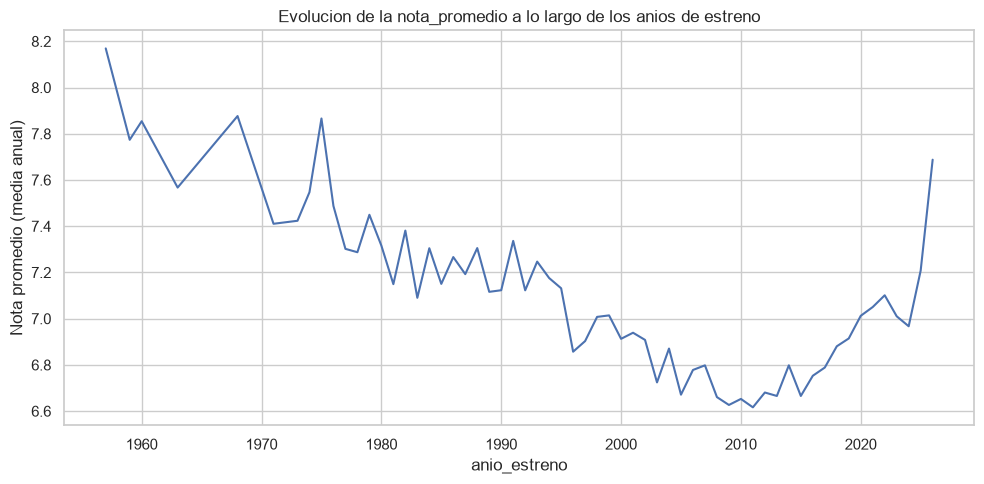

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
evol = df.groupby("anio_estreno").agg(nota_promedio=("nota_promedio", "mean"), cantidad=("id", "count"))
evol = evol[evol["cantidad"] >= 5]  # se ignoran anios con muy pocas peliculas en el dataset
sns.lineplot(data=evol, x=evol.index, y="nota_promedio", ax=ax)
ax.set_title("Evolucion de la nota_promedio a lo largo de los anios de estreno")
ax.set_ylabel("Nota promedio (media anual)")
plt.tight_layout()
plt.show()


## 5. Correlaciones con la variable objetivo


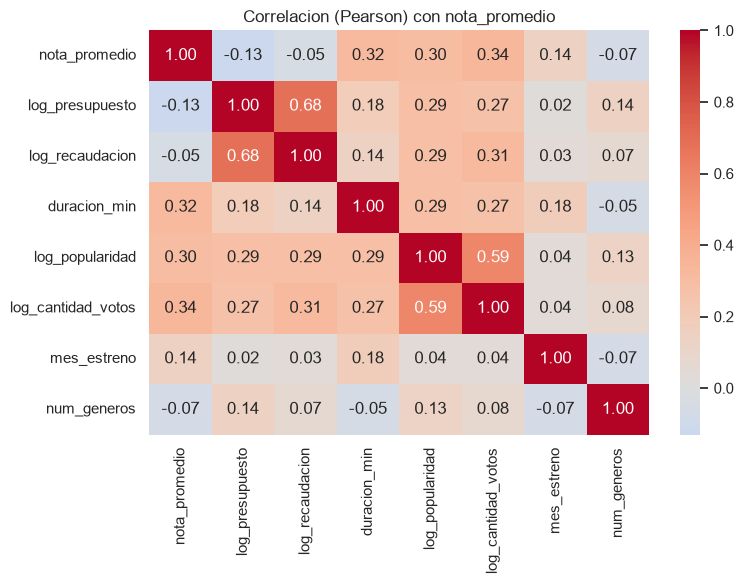

In [12]:
df_corr = df.copy()
for col in ["presupuesto", "recaudacion", "popularidad", "cantidad_votos"]:
    df_corr[f"log_{col}"] = np.log1p(df_corr[col])

corr_cols = ["nota_promedio", "log_presupuesto", "log_recaudacion", "duracion_min",
             "log_popularidad", "log_cantidad_votos", "mes_estreno", "num_generos"]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df_corr[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlacion (Pearson) con nota_promedio")
plt.tight_layout()
plt.show()


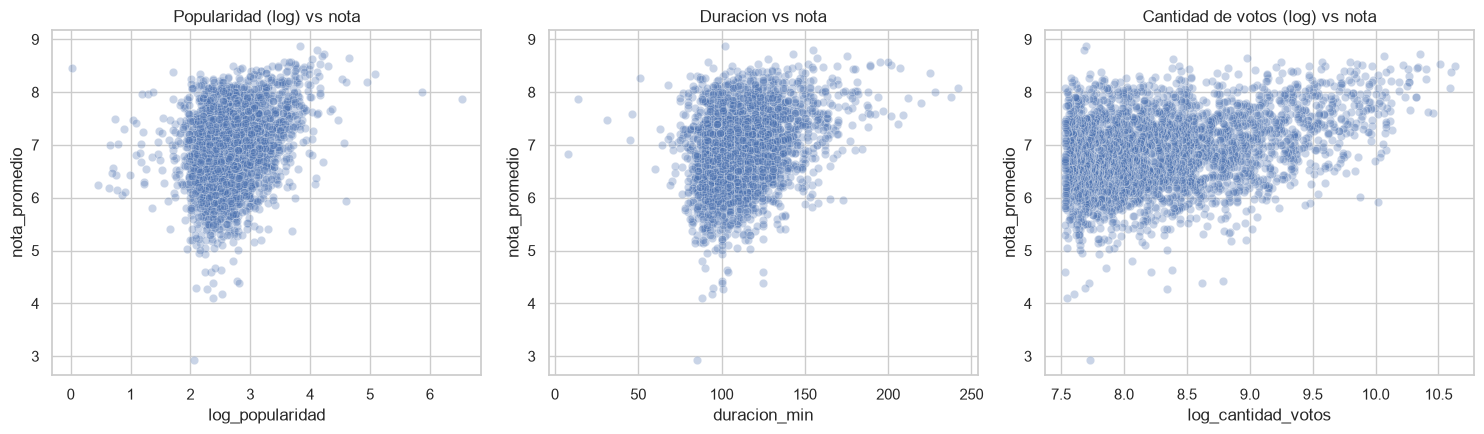

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.scatterplot(data=df_corr, x="log_popularidad", y="nota_promedio", alpha=0.3, ax=axes[0])
sns.scatterplot(data=df_corr, x="duracion_min", y="nota_promedio", alpha=0.3, ax=axes[1])
sns.scatterplot(data=df_corr, x="log_cantidad_votos", y="nota_promedio", alpha=0.3, ax=axes[2])
axes[0].set_title("Popularidad (log) vs nota")
axes[1].set_title("Duracion vs nota")
axes[2].set_title("Cantidad de votos (log) vs nota")
plt.tight_layout()
plt.show()


La duracion muestra una relacion positiva leve pero visible (peliculas mas
largas tienden a estar mejor calificadas, un patron conocido en la literatura
de recomendacion de contenido). La popularidad y la cantidad de votos tienen
una correlacion mas debil de lo esperable con la nota: ser muy visto o muy
popular no implica necesariamente estar mejor calificado.


## 6. Texto: longitud de la sinopsis


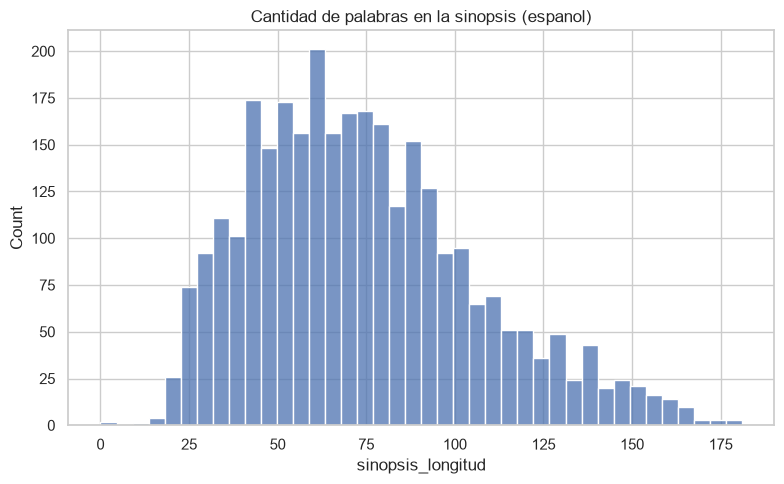

Peliculas sin sinopsis: 2


In [14]:
df["sinopsis_longitud"] = df["sinopsis_es"].fillna("").apply(lambda t: len(t.split()))

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df["sinopsis_longitud"], bins=40, ax=ax)
ax.set_title("Cantidad de palabras en la sinopsis (espanol)")
plt.tight_layout()
plt.show()

print(f"Peliculas sin sinopsis: {(df['sinopsis_longitud'] == 0).sum()}")


## 7. Limpieza para las siguientes etapas

Decisiones de limpieza, justificadas por lo observado arriba:

1. `presupuesto` y `recaudacion` en 0 se tratan como **faltante**, no como
   cero real: se crean columnas indicadoras (`presupuesto_conocido`,
   `recaudacion_conocido`) para que el modelo pueda distinguir "no hay dato"
   de "el valor es efectivamente bajo", y se imputa la mediana del resto de
   la columna (calculada solo con valores no nulos) para no perder esas filas.
2. Se descartan peliculas sin sinopsis (`sinopsis_longitud == 0`): sin texto
   no se puede calcular ni TF-IDF de reparto (ya viene de otra fuente) ni
   sentimiento, y en la practica son una fraccion muy chica del dataset.
3. Se conserva el resto de las columnas crudas: las transformaciones
   (logaritmos, TF-IDF, sentimiento, codificacion de generos) se aplican en
   `03_feature_engineering.ipynb`, no aca.


In [15]:
df_clean = df.copy()

for col in ["presupuesto", "recaudacion"]:
    conocido = df_clean[col] > 0
    df_clean[f"{col}_conocido"] = conocido.astype(int)
    mediana = df_clean.loc[conocido, col].median()
    df_clean.loc[~conocido, col] = mediana

df_clean = df_clean[df_clean["sinopsis_longitud"] > 0].reset_index(drop=True)

for col in list_cols:
    df_clean[col] = df_clean[col].apply(lambda lst: json.dumps(lst, ensure_ascii=False))

paths.DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
df_clean.to_csv(paths.EDA_CLEAN_CSV, index=False, encoding="utf-8-sig")

print(f"Dataset limpio: {df_clean.shape[0]} filas x {df_clean.shape[1]} columnas")
print(f"Guardado en: {paths.EDA_CLEAN_CSV.relative_to(paths.PROJECT_ROOT)}")


Dataset limpio: 2998 filas x 28 columnas
Guardado en: data\processed\peliculas_clean.csv
